<a href="https://colab.research.google.com/github/MDankloff/Delayed-Fairness-Project/blob/main/BAF_TryOut_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAF calibrated version of cloned_ltf_pop.

same pipeline: generator/ simulator/ fair_model / baseline / utils / evaluation (LR, LCF, EO, DP)

same run and evaluate () workflow only the data source is BAF and the Banks ground truth bias change.

Sensitive attribute: income (split at 0.6 income), not age.
generator (k_same/k_other) thus works same.

In [37]:
#[Cell] Clone / mount, same as cloned_ltf_pop
!git clone https://github.com/MDankloff/Delayed-Fairness-Project.git
%cd Delayed-Fairness-Project
!git pull origin main

import sys
sys.path.append('Synthetic/src')

Cloning into 'Delayed-Fairness-Project'...
remote: Enumerating objects: 1150, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 1150 (delta 133), reused 121 (delta 70), pack-reused 949 (from 1)
Receiving objects: 100% (1150/1150), 16.30 MiB | 26.42 MiB/s, done.
Resolving deltas: 100% (466/466), done.
/content/Delayed-Fairness-Project/Delayed-Fairness-Project/Delayed-Fairness-Project/Delayed-Fairness-Project
From https://github.com/MDankloff/Delayed-Fairness-Project
 * branch            main       -> FETCH_HEAD
Already up to date.


# Libraries

In [39]:
import os, sys

repo_url = "https://github.com/MDankloff/Delayed-Fairness-Project.git"
repo_dir = "/content/Delayed-Fairness-Project"

if not os.path.exists(repo_dir):
    os.system(f"git clone {repo_url} {repo_dir}")
else:
    os.system(f"git -C {repo_dir} pull origin main")

src_path = os.path.join(repo_dir, "Synthetic", "src")   # capital S
assert os.path.exists(os.path.join(src_path, "generator.py")), f"generator.py not found at {src_path}"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Using:", src_path)

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
# import os # Already imported above
import joblib

import generator as gen_mod
from generator import Agent as GenAgentBase        # used for the training-data bootstrap
from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples


#!pip install mesa pandas scikit-learn networkx
#!pip install mesa==1.2.1
#from mesa import Model, Agent
#from mesa.time import RandomActivation
#from collections import defaultdict

Using: /content/Delayed-Fairness-Project/Synthetic/src


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load BAF data

Saved parquet files from csv

In [40]:
from google.colab import drive
drive.mount('/content/drive')
!cd '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
base_path = '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF/parquet data'

extension = "parquet" #parquet for smaller files, csv available
data_paths = glob.glob(f"{base_path}/*.{extension}")

def read_dataset(path, ext = extension):
    if ext == "csv":
      return pd.read_csv(path)
    elif ext == "parquet":
      return pd.read_parquet(path)
    else:
      raise ValueError(f"Unsupported file extension: {ext}")

# Extract variant name from the file path (without the extension)
def get_variant(path):
    return os.path.basename(path).split(".")[0]

# Dictionary comprehension to read all CSV files into a dictionary of DataFrames
dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}
print(f"Loaded datasets: {list(dataframes.keys())}")

datasets_paths = {
    "Base": base_path + "/Base.parquet", # sampled to best represent original dataset
    "Variant I": base_path + "/Variant I.parquet", # higher group size disparity than base - reducing the size of the minority group from approx 20 - 10% of the dataset
    "Variant II": base_path + "/Variant II.parquet", # higher prevalence disparity than base - one group has 5 x the fraud detection rate of the other while group sizes are equal
    "Variant III": base_path + "/Variant III.parquet", # better separability for one of the groups -
    "Variant IV": base_path + "/Variant IV.parquet", # higher prevalence disparity in train
    "Variant V": base_path + "/Variant V.parquet", # better separability in train for one of the groups
}

Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


In [12]:
#Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

#for better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

#df4 = variant4 #set to preferred variant
#new_df4 = df4.copy()

base_df = base.copy() #set to preferred variant

# Explore Data

In [21]:
#base_df.info()

In [13]:
#make a simplified df containing only a few features
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score']].copy()
#df4_simple['month'].unique()

In [32]:
# Display descriptive statistics for the 'income' column
display(base_simple['income'].describe())

,income
count,1000000.000000
mean,0.562696
std,0.290343
min,0.100000
25%,0.300000
50%,0.600000
75%,0.800000
max,0.900000


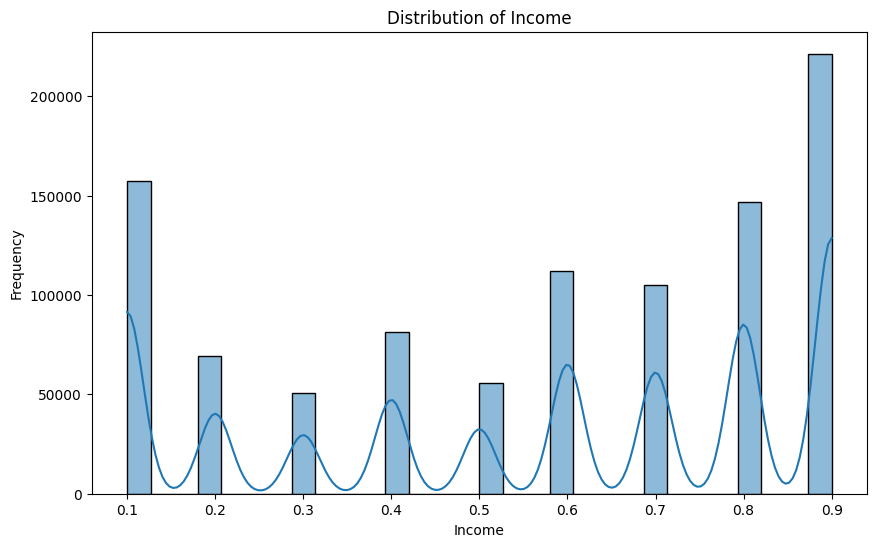

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(base_simple['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

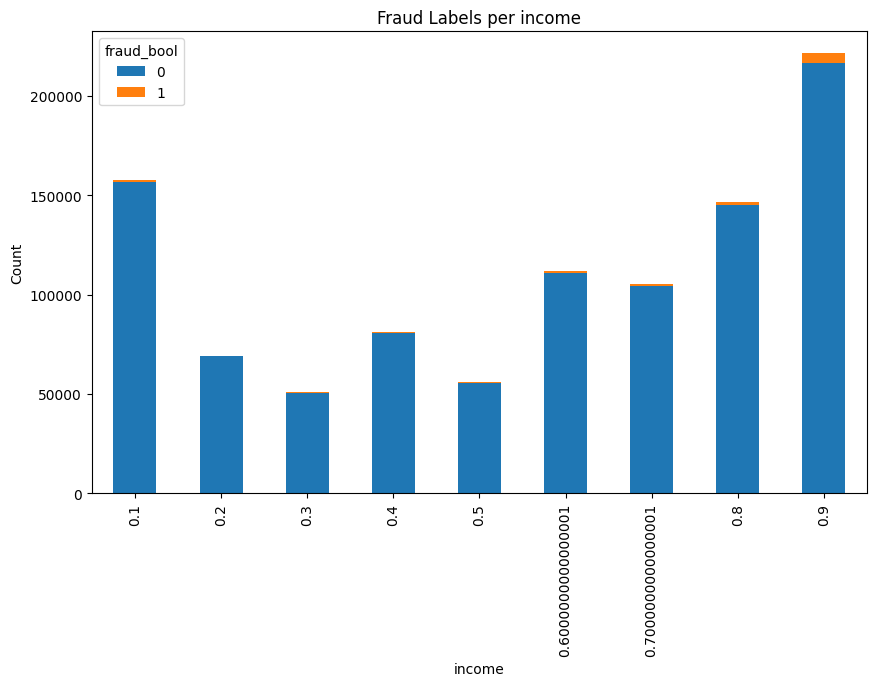

In [14]:
#fraud per income
fraud_per_month = base_simple.groupby(['income','fraud_bool']).size().unstack()
fraud_per_month.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels per income')
plt.xlabel('income')
plt.ylabel('Count')
plt.show()

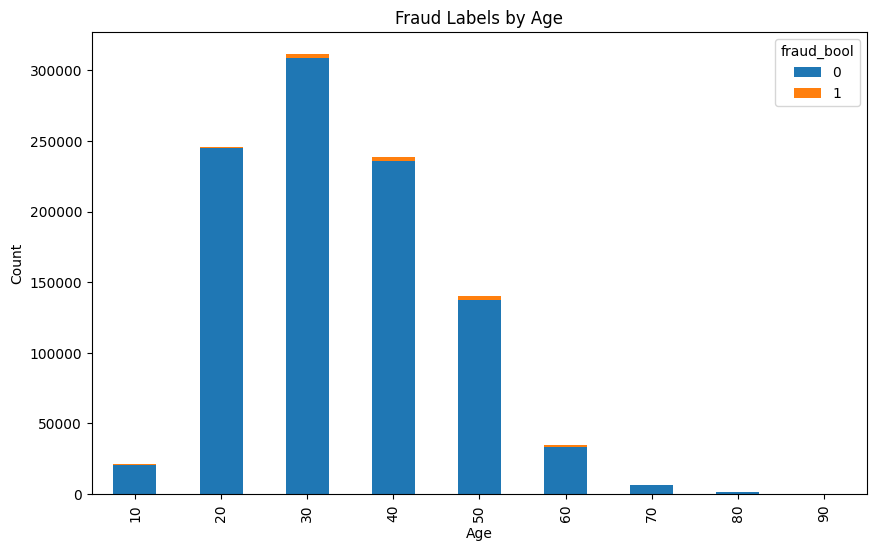

In [15]:
#fraud per age
fraud_per_age = base_simple.groupby(['customer_age','fraud_bool']).size().unstack()
fraud_per_age.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [25]:
print(base_simple.iloc[0])

fraud_bool             0.0
customer_age          40.0
income                 0.3
credit_risk_score    163.0
Name: 0, dtype: float64


In [24]:
print(base_simple['income_group'].value_counts())
print(base_simple.groupby('income_group')['fraud_bool'].mean())

income_group
High    585151
Low     414849
Name: count, dtype: int64
income_group
High    0.014189
Low     0.006571
Name: fraud_bool, dtype: float64


In [25]:
base_simple.groupby('group')['income'].mean()   # mean income by age group
# or
pd.crosstab(base_simple['group'], base_simple['income_group'])

income_group,High,Low
group,,
Older,114574,68439
Younger,470577,346410


# Create demographic groups

In [26]:
# define age groups - according to BAF authors
base_simple['group'] = np.where(base_simple['customer_age'] >= 50, 'Older', 'Younger')

  # split in 2 groups
group_young = base_simple[base_simple['group'] == 'Younger']
group_old = base_simple[base_simple['group'] == 'Older']

print(len(group_young), len(group_old))

# income is decile-bucketed in BAF, so many rows share median
#  value -- a plain > or >= threshold pushes that whole tied block to one
#  side and breaks the balance, as we saw with 0.600 giving 58.5/41.5)

median_income = base_simple['income'].median()
print(f"Median income: {median_income}")

above = base_simple['income'] > median_income
below = base_simple['income'] < median_income
tied  = base_simple['income'] == median_income

n_total = len(base_simple)
target_high = n_total // 2
n_above = above.sum()
n_needed_from_tied = max(0, target_high - n_above)

rng = np.random.default_rng(42)
tied_idx = base_simple.index[tied].to_numpy()
rng.shuffle(tied_idx)
high_tied_idx = set(tied_idx[:n_needed_from_tied])

base_simple['income_group'] = np.where(
    above, 'High',
    np.where(below, 'Low',
             np.where(base_simple.index.isin(high_tied_idx), 'High', 'Low'))
)

display(base_simple['income_group'].value_counts())
print(base_simple.groupby('income_group')['fraud_bool'].mean())

816987 183013
Median income: 0.6000000000000001


,count
income_group,
Low,500000
High,500000


income_group
High    0.015120
Low     0.006938
Name: fraud_bool, dtype: float64


fraud-rate gap by income: the nr Bank.params gets - calibrated against below.

<Axes: xlabel='income_group'>

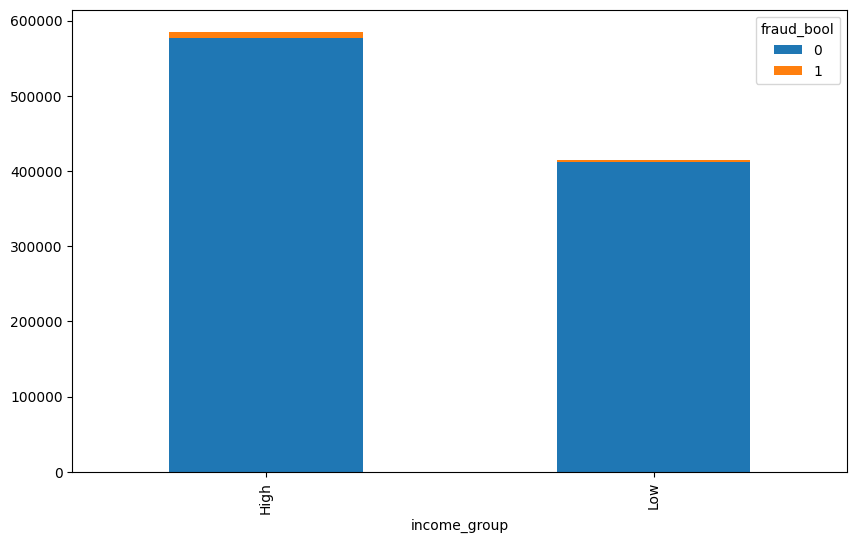

In [20]:
fraud_income_low=base_simple.groupby(['income_group','fraud_bool']).size().unstack()
fraud_income_low.plot(kind='bar', stacked=True, figsize=(10, 6))